# Check train-axis alignment

The GMD, VLS, and TOF arrays in a combined H5 file are stacked along
the same train axis, but the raw streams come from different DAQs
and the train-ID matching may be off by a few trains. This notebook
treats the GMD as ground truth and sweeps a small range of integer
train-index offsets for every other per-shot detector, picking the
offset that maximises the Pearson correlation against the GMD.

Per-shot scalars used:

- **electrons**: total non-zero hits per shot in `tofs_e` (cfg 1)
  or `liq_tofs_e` (cfg 2), inside `E_TOF_RANGE`.
- **ions** (cfg 1 only): total hits in `tofs_i` inside `I_TOF_RANGE`.
- **integrated VLS** (cfg 2 only): `nansum(vls, axis=-1)` after
  cropping and background subtraction.

Preprocessing applied before the correlation sweep:

1. (cfg 2) crop the VLS to `VLS_ROI` and auto-subtract the background
   over `VLS_BACKGROUND_ROI`.
2. Trim the bunch axis to `BUNCH_RANGE` so off-train bunches do not
   dilute the correlation.
3. Optionally restrict the GMD to `GMD_RANGE` so the correlation is
   not dominated by no-shot / saturated outliers.

In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from data_loading import load_data
from processing import count_hits

%matplotlib inline

## Parameters

In [8]:
# --- File / config --------------------------------------------------
CONFIG     = 1
H5_FILE    = config.COMBINED_DIR / ("test_config1.h5" if CONFIG == 1
                                    else "test_config2.h5")
TRIM_START = 3
TRIM_END   = 3
DOWNSAMPLE_N = 1

# --- Bunch-axis trim ------------------------------------------------
# Half-open [start, end) range of bunch indices to keep before the
# correlation. Choose to cover only the FEL bunch train.
BUNCH_RANGE = (0, 60)

# --- VLS preprocessing (config 2 only; ignored for config 1) -------
VLS_ROI            = (380, 500)
VLS_BACKGROUND_ROI = (60, 100)

# --- Per-detector TOF integration windows --------------------------
# None on either side means no bound on that side.
E_TOF_RANGE = (None, None)
I_TOF_RANGE = (None, None)

# --- GMD prefilter --------------------------------------------------
# (lo, hi) in uJ. Either may be None. Shots outside this range are
# dropped before computing Pearson r. Set to None to disable.
GMD_RANGE = (1.0, None)

# --- Offset sweep ---------------------------------------------------
# Integer train-index offsets to test. Offset k pairs GMD train i
# with detector train i + k.
OFFSETS = np.arange(-5, 6)

## Load and preprocess

In [ ]:
data = load_data(str(H5_FILE), config=CONFIG,
                 trim_start=TRIM_START, trim_end=TRIM_END,
                 downsample_N=DOWNSAMPLE_N)
print(f"file              : {H5_FILE}")
print(f"config            : {CONFIG}")
print(f"n_trains          : {data.n_trains}")
print(f"n_bunches (raw)   : {data.n_bunches}")

if CONFIG == 2:
    data = data.crop_vls(*VLS_ROI)
    data = data.auto_subtract_background(VLS_BACKGROUND_ROI)
    print(f"vls cropped to    : {VLS_ROI}")
    print(f"vls bg roi        : {VLS_BACKGROUND_ROI}")

data = data.trim_bunches(*BUNCH_RANGE)
print(f"bunch range kept  : {BUNCH_RANGE} -> n_bunches = {data.n_bunches}")

## Correlation-vs-offset helper

`gmd` is the ground truth; `detector` is any per-shot `(n_trains,
n_bunches)` scalar. Positive offsets shift the detector forward in
train index (pair GMD train `i` with detector train `i + k`). The
GMD prefilter is applied after alignment so the same shot count
convention holds at every offset.

In [4]:
def correlation_vs_offset(gmd, detector, offsets, gmd_range=None):
    """
    Pearson r between GMD and another per-shot detector vs train offset.

    Parameters
    ----------
    gmd : np.ndarray
        Per-shot GMD, shape ``(n_trains, n_bunches)``.
    detector : np.ndarray
        Per-shot detector scalar, same shape as ``gmd``.
    offsets : iterable of int
        Train-index offsets to test. Offset ``k`` pairs GMD train
        ``i`` with detector train ``i + k``.
    gmd_range : tuple of (float or None), optional
        ``(lo, hi)`` in uJ. Shots whose aligned GMD lies outside
        this band are dropped before the correlation. Either bound
        may be ``None``. ``None`` disables the prefilter entirely.

    Returns
    -------
    rs : np.ndarray
        Pearson r at each offset, shape ``(len(offsets),)``. NaN
        where fewer than two finite shots survive.
    ns : np.ndarray
        Number of finite shots used at each offset.
    """
    offsets = np.asarray(offsets, dtype=int)
    n = gmd.shape[0]
    rs = np.full(offsets.size, np.nan)
    ns = np.zeros(offsets.size, dtype=int)
    for i, k in enumerate(offsets):
        if k >= 0:
            g = gmd[: n - k]
            d = detector[k:]
        else:
            g = gmd[-k:]
            d = detector[: n + k]
        gf = g.ravel().astype(float)
        df = d.ravel().astype(float)
        keep = np.isfinite(gf) & np.isfinite(df)
        if gmd_range is not None:
            lo, hi = gmd_range
            if lo is not None:
                keep &= gf >= lo
            if hi is not None:
                keep &= gf <= hi
        if keep.sum() < 2:
            continue
        gv, dv = gf[keep], df[keep]
        if gv.std() == 0 or dv.std() == 0:
            continue
        rs[i] = float(np.corrcoef(gv, dv)[0, 1])
        ns[i] = int(keep.sum())
    return rs, ns

## Build per-shot detector scalars

One `(n_trains, n_bunches)` scalar per available detector. The set
depends on `CONFIG`.

In [5]:
detectors = {}

if CONFIG == 1:
    detectors["electrons (tofs_e)"] = count_hits(
        data.tofs_e, *E_TOF_RANGE
    ).astype(float)
    detectors["ions (tofs_i)"] = count_hits(
        data.tofs_i, *I_TOF_RANGE
    ).astype(float)
else:
    if data.liq_tofs_e is not None:
        detectors["electrons (liq_tofs_e)"] = count_hits(
            data.liq_tofs_e, *E_TOF_RANGE
        ).astype(float)
    detectors["integrated VLS"] = np.nansum(data.vls, axis=-1)

for name, arr in detectors.items():
    print(f"{name:25s} shape={arr.shape}  finite={np.isfinite(arr).sum()}")

electrons (liq_tofs_e)    shape=(4414, 60)  finite=264840
integrated VLS            shape=(4414, 60)  finite=264840


## Sweep offsets

In [6]:
results = {}
for name, det in detectors.items():
    rs, ns = correlation_vs_offset(
        data.gmd, det, OFFSETS, gmd_range=GMD_RANGE,
    )
    results[name] = (rs, ns)
    best_idx = int(np.nanargmax(rs))
    best_offset = int(OFFSETS[best_idx])
    best_r = float(rs[best_idx])
    print(f"{name:25s} best offset = {best_offset:+d}  "
          f"r = {best_r:.4f}  (n = {ns[best_idx]})")

electrons (liq_tofs_e)    best offset = +1  r = 0.3356  (n = 3730)
integrated VLS            best offset = +5  r = 0.0286  (n = 3730)


## Plot Pearson r vs offset

One line per detector. The vertical marker on each line is the
offset of the maximum. An aligned dataset peaks at offset 0; a
non-zero peak indicates how many trains the detector stream is
shifted relative to the GMD.

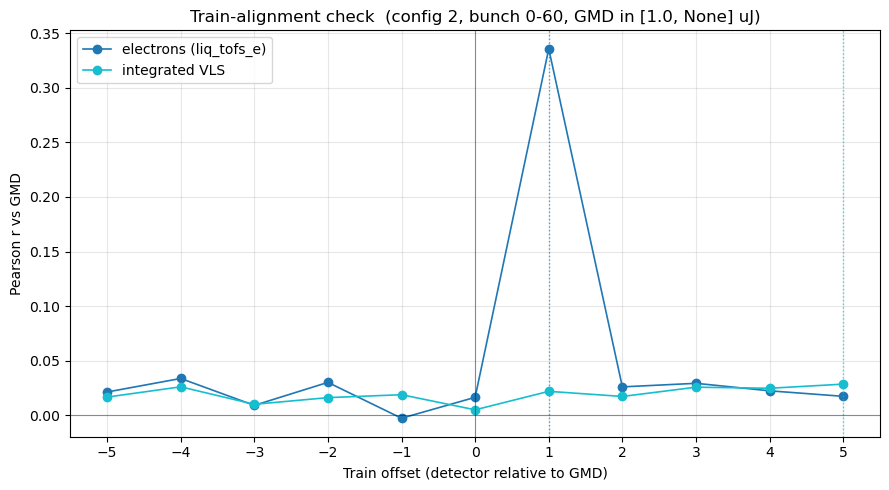

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(results), 1)))
for (name, (rs, ns)), color in zip(results.items(), colors):
    ax.plot(OFFSETS, rs, marker="o", lw=1.2, color=color, label=name)
    best_idx = int(np.nanargmax(rs))
    ax.axvline(OFFSETS[best_idx], color=color, ls=":", lw=1, alpha=0.7)
ax.axvline(0, color="black", lw=0.8, alpha=0.4)
ax.axhline(0, color="black", lw=0.8, alpha=0.4)
ax.set_xlabel("Train offset (detector relative to GMD)")
ax.set_ylabel("Pearson r vs GMD")
gmd_lo, gmd_hi = (GMD_RANGE if GMD_RANGE is not None else (None, None))
ax.set_title(
    f"Train-alignment check  (config {CONFIG}, bunch {BUNCH_RANGE[0]}-"
    f"{BUNCH_RANGE[1]}, GMD in [{gmd_lo}, {gmd_hi}] uJ)"
)
ax.set_xticks(OFFSETS)
ax.grid(alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plt.show()